# The other models — not the same thing as the poker table win %

This part confused me at first: **two families** of models live in this repo.

1. **Simulator / stage win %** — rich card + board features rebuilt every street (`build_stage_feature_payload`). That’s what notebook 02 dug into. Training entry point: `model_train.py` → `poker_models.pkl`.

2. **Dashboard tabs** (`main.py`) — lighter tabular models trained on player-ish aggregates:
   - **`win_predictor`** — logistic regression on `preflop_equity` proxy, seat encoding, stacks, table size → probability style outcome vs `net_result`.
   - **`bluff_predictor`** — aggression + streak + strength proxy vs heuristic `is_bluffing` label.
   - **`money_predictor`** — regress-style mapping from similar inputs → chips (`net_result`).

Those features all sit in `cleanedGambling.csv` because I engineered them in notebook 01. Below I’m just training quick diagnostics on a **subset** so plots render fast — same APIs the scripts expose (`train_win_model`, etc.).

## Load cleaned rows + grab a random subset
40k rows is plenty for "does anything stick out" plots without melting my laptop.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scripts.models.bluff_predictor import FEATURES as BLUFF_FEATURES, train_bluff_models
from scripts.models.money_predictor import FEATURES as MONEY_FEATURES, train_money_models
from scripts.models.win_predictor import FEATURES as WIN_FEATURES, train_win_model

sns.set_theme(style="whitegrid")

df = pd.read_csv(ROOT / "data" / "cleanedGambling.csv")
sample = df.sample(min(40000, len(df)), random_state=42)
print("sample:", sample.shape)
print("WIN_FEATURES:", WIN_FEATURES)
print("BLUFF_FEATURES:", BLUFF_FEATURES)
print("MONEY_FEATURES:", MONEY_FEATURES)

sample: (40000, 64)
WIN_FEATURES: ['preflop_equity', 'table_position', 'starting_stack', 'table_size']
BLUFF_FEATURES: ['aggression_score', 'strength_mean', 'starting_stack', 'win_streak', 'loss_streak']
MONEY_FEATURES: ['aggression_score', 'strength_mean', 'starting_stack', 'preflop_equity', 'table_size']


## Win model — coefficients tell a story (linear-ish)
Because it’s logistic + scaling, signed coefficients are easier to narrate than forest splits: "holding other inputs fixed, higher X pushes log-odds up/down".

metrics: {'auc': 0.6186977038066485, 'brier': 0.23019407178767687}


C:\Users\garrido-lestachebeli\AppData\Local\Temp\ipykernel_13592\2980367397.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, y="feature", x="coef", ax=ax, palette="coolwarm")


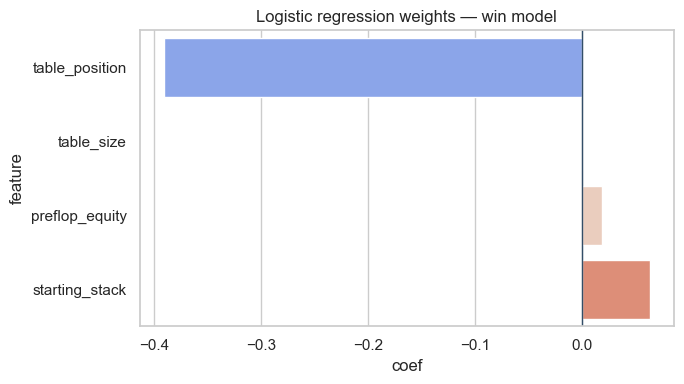

In [2]:
win_bundle = train_win_model(sample)
print("metrics:", win_bundle["metrics"])

pipe = win_bundle["model"]
coef = pipe.named_steps["model"].coef_.ravel()
feat_df = pd.DataFrame({"feature": WIN_FEATURES, "coef": coef}).sort_values("coef")
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=feat_df, y="feature", x="coef", ax=ax, palette="coolwarm")
ax.set_title("Logistic regression weights — win model")
ax.axvline(0, color="#334E68", lw=1)
plt.tight_layout()
plt.show()

## Bluff model — forest importances
Labels come from a heuristic (`label_bluffs` in notebook 01 pipeline), so interpret cautiously — you’re mostly checking that **something** is learning signal vs noise.

metrics: {'auc_logit': 0.9893522484535624, 'auc_forest': 1.0, 'selected_threshold': 0.035}


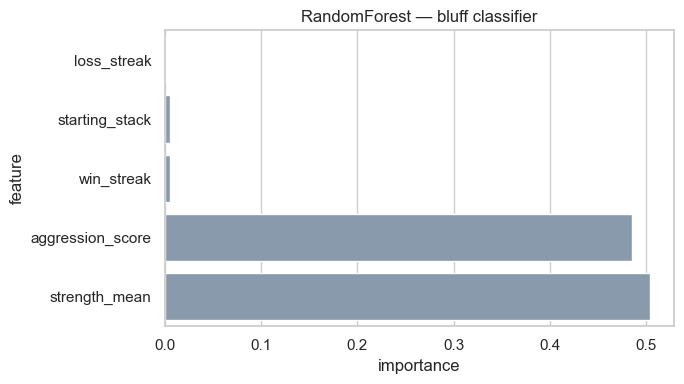

In [3]:
bluff_bundle = train_bluff_models(sample)
print("metrics:", bluff_bundle["metrics"])

forest = bluff_bundle["alternate_model"]
imp = (
    pd.DataFrame({"feature": BLUFF_FEATURES, "importance": forest.feature_importances_})
    .sort_values("importance")
)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=imp, y="feature", x="importance", ax=ax, color="#829AB1")
ax.set_title("RandomForest — bluff classifier")
plt.tight_layout()
plt.show()

## Money model — chip prediction baseline
Same forest family as implemented in `money_predictor.py`; metrics dict tells me how embarrassingly high MAE is on held-out rows (expected for noisy outcomes).

metrics: {'baseline_mae': 78.182171875, 'baseline_rmse': 155.5168030774227, 'robust_mae': 73.2321622836032, 'robust_rmse': 150.74323244589854}


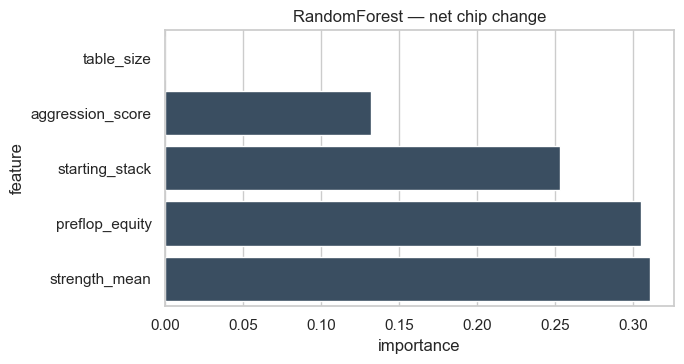

In [4]:
money_bundle = train_money_models(sample)
print("metrics:", money_bundle["metrics"])

base = money_bundle["baseline_model"]
imp = (
    pd.DataFrame({"feature": MONEY_FEATURES, "importance": base.feature_importances_})
    .sort_values("importance")
)
fig, ax = plt.subplots(figsize=(7, 3.8))
sns.barplot(data=imp, y="feature", x="importance", ax=ax, color="#334E68")
ax.set_title("RandomForest — net chip change")
plt.tight_layout()
plt.show()

### Closing thought
If someone asks "what model powers what": **poker table %** uses `stage_win_predictor` + `poker_models.pkl`; **these three** are the lighter dashboard experiments sitting next to it in `scripts/models/`.

**Next:** notebook 04 — smoke-test that a synthetic flop payload still scores once `model_train.py` has been run.